In [1]:
import sys
print(sys.executable)


C:\Users\kisho\OneDrive\Desktop\GOLD\venv\Scripts\python.exe


In [2]:
import sys
sys.path.append(r"C:\Users\kisho\OneDrive\Desktop\GOLD")


In [3]:
import os
from dotenv import load_dotenv

load_dotenv(r"C:\Users\kisho\OneDrive\Desktop\GOLD\.env")

print("Account:", os.getenv("SNOWFLAKE_ACCOUNT"))
print("User:", os.getenv("SNOWFLAKE_USER"))


Account: pe11654.central-india.azure
User: KISHORE97890


In [4]:
from snowflake.snowflake_connection import get_session

session = get_session()

df = session.sql("SELECT CURRENT_TIMESTAMP()").to_pandas()
df


Connecting to: pe11654.central-india.azure
Using schema: PROCESSED


,CURRENT_TIMESTAMP()
0,2025-12-09 06:35:46.358000-08:00


In [5]:
session = get_session()
session.sql("SHOW TABLES IN GOLD_PROJECT.PROCESSED").to_pandas()


Connecting to: pe11654.central-india.azure
Using schema: PROCESSED


,"""created_on""","""name""","""database_name""","""schema_name""","""kind""","""comment""","""cluster_by""","""rows""","""bytes""","""owner""",...,"""automatic_clustering""","""change_tracking""","""is_external""","""enable_schema_evolution""","""owner_role_type""","""is_event""","""is_hybrid""","""is_iceberg""","""is_dynamic""","""is_immutable"""
0,2025-12-09 06:20:59.309000-08:00,CHRONOS_FORECAST,GOLD_PROJECT,PROCESSED,TABLE,,,0,0,ACCOUNTADMIN,...,OFF,OFF,N,N,ROLE,N,N,N,N,N
1,2025-12-03 04:15:55.909000-08:00,GOLD_PRICES_RAW,GOLD_PROJECT,PROCESSED,TABLE,,,0,0,ACCOUNTADMIN,...,OFF,OFF,N,N,ROLE,N,N,N,N,N
2,2025-12-05 05:37:57.076000-08:00,MASTER_GOLD_DATA,GOLD_PROJECT,PROCESSED,TABLE,,,6334,129024,ACCOUNTADMIN,...,OFF,OFF,N,N,ROLE,N,N,N,N,N
3,2025-12-05 05:58:46.040000-08:00,MASTER_WITH_INDICATORS,GOLD_PROJECT,PROCESSED,TABLE,,,6334,965632,ACCOUNTADMIN,...,OFF,OFF,N,N,ROLE,N,N,N,N,N
4,2025-12-03 05:17:52.675000-08:00,USDINR_RAW,GOLD_PROJECT,PROCESSED,TABLE,,,0,0,ACCOUNTADMIN,...,OFF,OFF,N,N,ROLE,N,N,N,N,N


In [7]:
from snowflake.snowflake_connection import get_session
from app.models.chronos_t5_model import ChronosT5Model

# Create session
session = get_session()

# Force correct schema and database
session.use_database("GOLD_PROJECT")
session.use_schema("PROCESSED")

df = session.table("MASTER_WITH_INDICATORS").to_pandas()

df.head()


Connecting to: pe11654.central-india.azure
Using schema: PROCESSED


,DATE,GOLD_CLOSE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_VOLUME,DXY,CRUDE_OIL,SP500,USDINR,...,MACD_SIGNAL,MACD_HIST,BB_LOWER,BB_MIDDLE,BB_UPPER,ATR,STOCH_K,STOCH_D,MOMENTUM10,ROC
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0,98.935997,59.23,6705.120117,90.124001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000-08-31,278.299988,274.799988,278.299988,274.799988,0,98.935997,59.23,6705.120117,90.124001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,98.935997,59.23,6705.120117,90.124001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,98.935997,59.23,6705.120117,90.124001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,98.935997,59.23,6705.120117,90.124001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
series = df["GOLD_CLOSE"].values
df.columns


Index(['DATE', 'GOLD_CLOSE', 'GOLD_OPEN', 'GOLD_HIGH', 'GOLD_LOW',
       'GOLD_VOLUME', 'DXY', 'CRUDE_OIL', 'SP500', 'USDINR', 'CPI', 'US10Y',
       'VIX', 'SMA10', 'SMA20', 'SMA50', 'EMA12', 'EMA26', 'RSI14', 'MACD',
       'MACD_SIGNAL', 'MACD_HIST', 'BB_LOWER', 'BB_MIDDLE', 'BB_UPPER', 'ATR',
       'STOCH_K', 'STOCH_D', 'MOMENTUM10', 'ROC'],
      dtype='object')

In [9]:
from app.models.chronos_t5_model import ChronosT5Model

model = ChronosT5Model()

next_day = model.predict_next(series, prediction_length=1)
next_week = model.predict_next(series, prediction_length=7)
next_month = model.predict_next(series, prediction_length=30)

print("Next day:", next_day)
print("Next week:", next_week)
print("Next month:", next_month)


Next day: [[4307.5986]
 [4307.5986]
 [4266.574 ]
 [4020.4233]
 [4287.085 ]
 [4225.5493]
 [4246.0605]
 [4246.0605]
 [4225.5493]
 [4081.9617]
 [4225.5493]
 [4246.0605]
 [4266.574 ]
 [4184.525 ]
 [4225.5493]
 [4205.0356]
 [4307.5986]
 [4287.085 ]
 [4246.0605]
 [4205.0356]]
Next week: [[4266.574  4328.11   4307.5986 4287.085  4307.5986 4287.085  4348.6235]
 [4307.5986 4348.6235 4389.6484 4471.6978 4574.258  4615.2827 4594.772 ]
 [4246.0605 4246.0605 4266.574  4287.085  4287.085  4307.5986 4328.11  ]
 [4246.0605 4307.5986 4348.6235 4369.135  4410.159  4512.722  4492.2085]
 [4266.574  4225.5493 4246.0605 4266.574  4287.085  4307.5986 4266.574 ]
 [4225.5493 4225.5493 4266.574  4246.0605 4266.574  4266.574  4266.574 ]
 [4266.574  4348.6235 4307.5986 4348.6235 4348.6235 4389.6484 4492.2085]
 [4369.135  4266.574  4246.0605 4307.5986 4328.11   4369.135  4389.6484]
 [4307.5986 4430.673  4410.159  4410.159  4430.673  4471.6978 4471.6978]
 [4328.11   4389.6484 4307.5986 4266.574  4328.11   4348.6235

In [10]:
import numpy as np

def summarize_forecast(name, arr):
    print(f"\n📌 {name} forecast:")
    print("Mean:", np.mean(arr))
    print("Median:", np.median(arr))
    print("Min:", np.min(arr))
    print("Max:", np.max(arr))


summarize_forecast("Next Day", next_day)
summarize_forecast("Next Week", next_week.reshape(-1))
summarize_forecast("Next Month", next_month.reshape(-1))



📌 Next Day forecast:
Mean: 4230.677
Median: 4246.0605
Min: 4020.4233
Max: 4307.5986

📌 Next Week forecast:
Mean: 4301.5913
Median: 4287.085
Min: 3794.7888
Max: 4615.2827

📌 Next Month forecast:
Mean: 4324.2124
Median: 4307.5986
Min: 3753.7642
Max: 4943.4805


In [11]:
one_day = float(np.mean(next_day))
one_week = list(np.mean(next_week, axis=0))
one_month = list(np.mean(next_month, axis=0))

print("\nOne-day:", one_day)
print("\nOne-week:", one_week)
print("\nOne-month:", one_month)



One-day: 4230.6767578125

One-week: [np.float32(4258.368), np.float32(4279.907), np.float32(4276.83), np.float32(4297.3423), np.float32(4312.726), np.float32(4340.418), np.float32(4345.5464)]

One-month: [np.float32(4244.01), np.float32(4246.061), np.float32(4253.24), np.float32(4284.009), np.float32(4301.4443), np.float32(4302.47), np.float32(4288.111), np.float32(4296.3164), np.float32(4304.521), np.float32(4319.905), np.float32(4311.7), np.float32(4309.649), np.float32(4328.11), np.float32(4314.777), np.float32(4319.9053), np.float32(4321.956), np.float32(4331.1875), np.float32(4327.085), np.float32(4343.4946), np.float32(4338.366), np.float32(4351.6997), np.float32(4357.8525), np.float32(4373.2373), np.float32(4373.2373), np.float32(4366.058), np.float32(4355.802), np.float32(4352.725), np.float32(4370.16), np.float32(4372.212), np.float32(4367.084)]


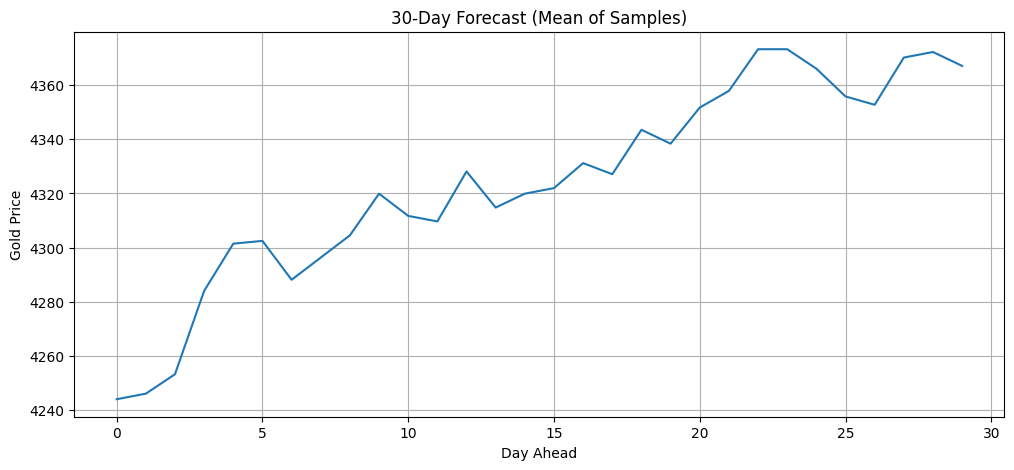

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(one_month)
plt.title("30-Day Forecast (Mean of Samples)")
plt.xlabel("Day Ahead")
plt.ylabel("Gold Price")
plt.grid(True)
plt.show()


In [13]:
import importlib
import app.viewmodels.save_chronos_forecast as scf
importlib.reload(scf)

from app.viewmodels.save_chronos_forecast import save_forecast


In [14]:
save_forecast("day", [one_day], auto_create_table=True)


               RUN_TIMESTAMP HORIZON           FORECAST
0 2025-12-09 20:07:10.903814     day  [4230.6767578125]


ProgrammingError: 002023 (22000): SQL compilation error:
Expression type does not match column data type, expecting TIMESTAMP_NTZ(9) but got NUMBER(38,0) for column RUN_TIMESTAMP

In [20]:
import os
print("Notebook working directory:", os.getcwd())


Notebook working directory: C:\Users\kisho


In [15]:
save_forecast("day", [one_day])
save_forecast("week", one_week)
save_forecast("month", one_month)


               RUN_TIMESTAMP HORIZON           FORECAST
0 2025-12-09 20:09:40.986505     day  [4230.6767578125]
               RUN_TIMESTAMP HORIZON  \
0 2025-12-09 20:09:44.163869    week   

                                            FORECAST  
0  [4258.368, 4279.907, 4276.83, 4297.3423, 4312....  
               RUN_TIMESTAMP HORIZON  \
0 2025-12-09 20:09:45.923479   month   

                                            FORECAST  
0  [4244.01, 4246.061, 4253.24, 4284.009, 4301.44...  
